# Agent 3 — Clustering K-Means (Aker Service)

Objectif : regrouper les offres par similarité de texte (`objet`), **séparément pour chaque volet** :
- Avis A.O (`cleaned_avis_ao.csv`)
- Shopping Mall (`cleaned_shopping_mall.csv`)

Méthode :
1. Vectorisation du texte (TF-IDF)
2. Recherche du K optimal par la **méthode du coude**
3. Clustering K-Means
4. Visualisation 2D de la séparation des clusters (PCA)
5. Sauvegarde des résultats (un fichier par volet, avec les colonnes `cluster`, `cluster_name` et `categorie_metier` en plus)


## Étape 0 — Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

try:
    from kneed import KneeLocator
    HAS_KNEED = True
except ImportError:
    HAS_KNEED = False
    print("kneed n'est pas installé (pip install kneed) : le K optimal sera à choisir vous-même sur le graphique.")


## Étape 1 — Chargement des données (les deux volets, séparément)


In [2]:
from pathlib import Path

# Cherche automatiquement le dossier app/data, peu importe d'où ce notebook
# est ouvert (évite les erreurs de chemin relatif si le fichier a été
# déplacé/dupliqué/téléchargé ailleurs que dans agents/).
CANDIDATS = [
    Path("../app/data"), Path("./app/data"), Path("app/data"),
    Path("../../app/data"), Path.cwd() / "app" / "data",
    Path.home() / "Desktop" / "Aker Service" / "app" / "data",   # filet de sécurité : chemin absolu direct
]
DATA_DIR = next((c for c in CANDIDATS if (c / "cleaned_avis_ao.csv").exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Impossible de trouver app/data/cleaned_avis_ao.csv automatiquement. "
        "Vérifiez que ce notebook se trouve bien dans le dossier agents/ du projet, "
        "et que agent2_cleaner.py a bien été exécuté avant."
    )
print(f"Dossier de données trouvé : {DATA_DIR.resolve()}")

df_avis_ao = pd.read_csv(DATA_DIR / "cleaned_avis_ao.csv")
df_shopping_mall = pd.read_csv(DATA_DIR / "cleaned_shopping_mall.csv")

print(f"Avis A.O       : {len(df_avis_ao)} lignes")
print(f"Shopping Mall  : {len(df_shopping_mall)} lignes")
df_avis_ao.head(3)


Dossier de données trouvé : C:\Users\user\Desktop\Aker Service\app\data
Avis A.O       : 461 lignes
Shopping Mall  : 100 lignes


,numero_ao,acheteur_public,date_publication,objet_ao,dernier_delai,categorie,jours_restants
0,20260805159,Groupe Chimique Tunisien,27/08/2026,GFI2620110 FOURNITURE D'UN (01) LOT DES MATERI...,13/10/2026 08:30,avis_ao,46
1,20260701423,Ministère de la Défense Nationale,27/08/2026,travaux de réaménagement des hangars a KEF ANB...,25/09/2026 10:00,avis_ao,28
2,20260805158,Commune Balta -Bouaouene,27/08/2026,Désignation d'un avocat ou d'un cabinet d'avoc...,15/09/2026 10:00,avis_ao,18


## Étape 2 — Fonctions réutilisables

On écrit ces fonctions une seule fois, puis on les applique aux deux volets séparément juste après.


In [3]:
# Mots trop génériques dans le vocabulaire des marchés publics tunisiens :
# ils apparaissent dans presque toutes les offres et ne sont pas distinctifs,
# donc on les exclut pour que les NOMS de clusters soient clairs.
STOPWORDS_FR = [
    "le", "la", "les", "de", "des", "du", "un", "une", "et", "ou", "pour", "dans",
    "sur", "au", "aux", "avec", "par", "en", "que", "qui", "est", "ce", "ces", "cette",
    "se", "sa", "son", "ses", "leur", "leurs", "il", "elle", "ils", "elles", "vous", "nous",
    "acquisition", "acquisitions", "fourniture", "fournitures", "fournir", "travaux",
    "prestation", "prestations", "consultation", "consultations", "realisation", "réalisation",
    "marche", "marché", "marches", "marchés", "objet", "annee", "année", "nationale", "national",
    "regionale", "régionale", "regional", "régional", "projet", "programme", "appel", "offre", "offres",
    "2024", "2025", "2026",
]


def vectorize_text(texts):
    """Vectorise une colonne de texte (français/arabe mélangés, on garde tel quel) en TF-IDF."""
    vectorizer = TfidfVectorizer(max_features=500, min_df=2, stop_words=STOPWORDS_FR)
    X = vectorizer.fit_transform(texts.fillna(""))
    return X, vectorizer


def elbow_method(X, k_min=2, k_max=15):
    """Calcule l'inertie pour chaque K et trace la courbe du coude."""
    # Sécurité : impossible d'avoir plus de clusters que d'échantillons.
    # On limite k_max en conséquence pour ne jamais planter sur un petit volume de données.
    k_max = min(k_max, max(k_min, X.shape[0] - 1))
    k_range = range(k_min, k_max + 1)
    inertias = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)

    plt.figure(figsize=(7, 4))
    plt.plot(list(k_range), inertias, marker="o")
    plt.xlabel("Nombre de clusters (K)")
    plt.ylabel("Inertie")
    plt.title("Méthode du coude")
    plt.grid(True)
    plt.show()

    k_suggested = None
    if HAS_KNEED:
        kl = KneeLocator(list(k_range), inertias, curve="convex", direction="decreasing")
        k_suggested = kl.elbow
        print(f"K optimal suggéré (kneed) : {k_suggested}")
    else:
        print("Regardez le graphique : le K optimal est au 'coude' (où la courbe cesse de baisser fortement).")

    return inertias, k_suggested


def plot_clusters_2d(X, labels, title):
    """Réduit le TF-IDF en 2D (PCA) et affiche les clusters en couleur."""
    X_dense = X.toarray()
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_dense)

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", s=25, alpha=0.8)
    plt.title(title)
    plt.xlabel("Composante 1")
    plt.ylabel("Composante 2")
    plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def name_clusters(vectorizer, kmeans, top_n=3):
    """
    Génère un nom clair et lisible pour chaque cluster à partir des mots
    les plus caractéristiques de son centre (après filtrage des mots-bruit).
    Ex: 'Médical / Laboratoire' au lieu d'une liste brute en minuscules.
    Retourne un dict {cluster_id: nom}.
    """
    feature_names = np.array(vectorizer.get_feature_names_out())
    names = {}
    for cluster_id, center in enumerate(kmeans.cluster_centers_):
        top_indices = center.argsort()[::-1][:top_n]
        top_words = [feature_names[i].capitalize() for i in top_indices if center[i] > 0]
        names[cluster_id] = " / ".join(top_words) if top_words else f"Cluster {cluster_id}"
    return names


## Volet 1 — Avis A.O
### Étape 3a — Vectorisation + méthode du coude


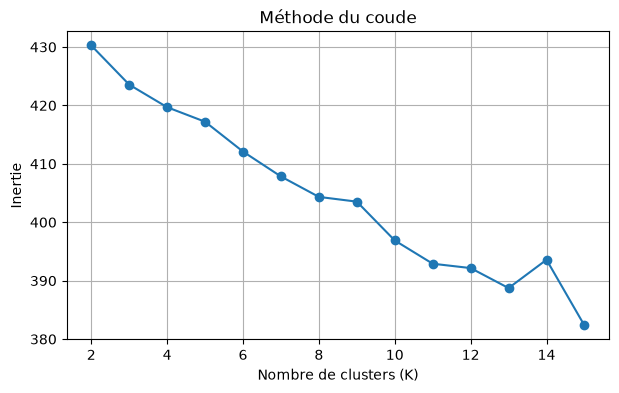

K optimal suggéré (kneed) : 11


In [4]:
X_ao, vectorizer_ao = vectorize_text(df_avis_ao["objet_ao"])
inertias_ao, k_suggested_ao = elbow_method(X_ao, k_min=2, k_max=15)


**Regardez le graphique ci-dessus** (et/ou le K suggéré affiché) puis fixez `K_AO` juste en dessous avant de continuer.


In [5]:
K_AO = k_suggested_ao if k_suggested_ao else 5   # <-- ajustez ce chiffre selon le coude observé
K_AO = max(2, min(K_AO, len(df_avis_ao) - 1))   # sécurité : jamais plus de clusters que de lignes

kmeans_ao = KMeans(n_clusters=K_AO, n_init=10, random_state=42)
df_avis_ao["cluster"] = kmeans_ao.fit_predict(X_ao)

print(f"Avis A.O : {K_AO} clusters")
df_avis_ao["cluster"].value_counts().sort_index()


Avis A.O : 11 clusters


cluster
0     215
1      23
2      17
3      32
4      29
5      39
6      35
7      23
8      28
9      14
10      6
Name: count, dtype: int64

### Étape 4a — Visualisation de la séparation des clusters (Avis A.O)


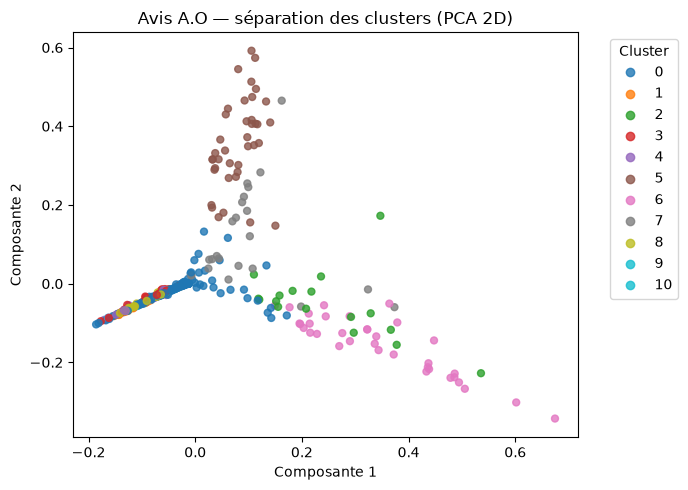

In [6]:
plot_clusters_2d(X_ao, df_avis_ao["cluster"], "Avis A.O — séparation des clusters (PCA 2D)")


### Étape 4a bis — Noms automatiques des clusters (Avis A.O)

Le K-means ne donne que des numéros ; on génère ici un nom lisible pour chaque cluster à partir de ses mots-clés dominants.


In [7]:
names_ao = name_clusters(vectorizer_ao, kmeans_ao, top_n=3)
for cluster_id, name in names_ao.items():
    print(f"Cluster {cluster_id} : {name}")


Cluster 0 : Mise / Profit / Installation
Cluster 1 : Entretien / Primaire / École
Cluster 2 : بناء / أشغال / استكمال
Cluster 3 : Deux / Lot / Tunisien
Cluster 4 : Aménagement / Réhabilitation / El
Cluster 5 : اقتناء / لفائدة / معدات
Cluster 6 : أشغال / تهيئة / إنجاز
Cluster 7 : عروض / طلب / عدد
Cluster 8 : Construction / Exécution / Cadre
Cluster 9 : Matériels / Achat / Informatiques
Cluster 10 : Réactifs / Mise / Place


**Si un nom généré automatiquement n'est pas assez clair pour un utilisateur final**, renommez-le à la main ci-dessous (regardez les exemples affichés plus loin, à l'Étape 6, pour décider). Sinon laissez ce dictionnaire vide.


In [8]:
NOMS_MANUELS_AO = {
    # 0: "Équipements médicaux",
    # 3: "Travaux de construction",
}
names_ao.update(NOMS_MANUELS_AO)


## Volet 2 — Shopping Mall
### Étape 3b — Vectorisation + méthode du coude


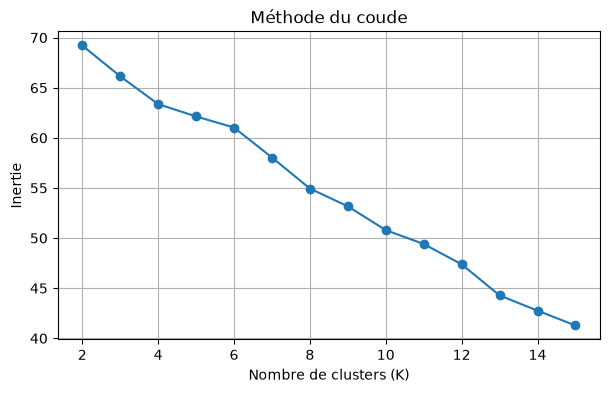

K optimal suggéré (kneed) : None


In [9]:
X_sm, vectorizer_sm = vectorize_text(df_shopping_mall["objet_consultation"])
inertias_sm, k_suggested_sm = elbow_method(X_sm, k_min=2, k_max=15)


Même logique : ajustez `K_SM` selon le coude observé ci-dessus.


In [10]:
K_SM = k_suggested_sm if k_suggested_sm else 5   # <-- ajustez ce chiffre selon le coude observé
K_SM = max(2, min(K_SM, len(df_shopping_mall) - 1))   # sécurité : jamais plus de clusters que de lignes

kmeans_sm = KMeans(n_clusters=K_SM, n_init=10, random_state=42)
df_shopping_mall["cluster"] = kmeans_sm.fit_predict(X_sm)

print(f"Shopping Mall : {K_SM} clusters")
df_shopping_mall["cluster"].value_counts().sort_index()


Shopping Mall : 5 clusters


cluster
0     2
1     5
2     5
3    84
4     4
Name: count, dtype: int64

### Étape 4b — Visualisation de la séparation des clusters (Shopping Mall)


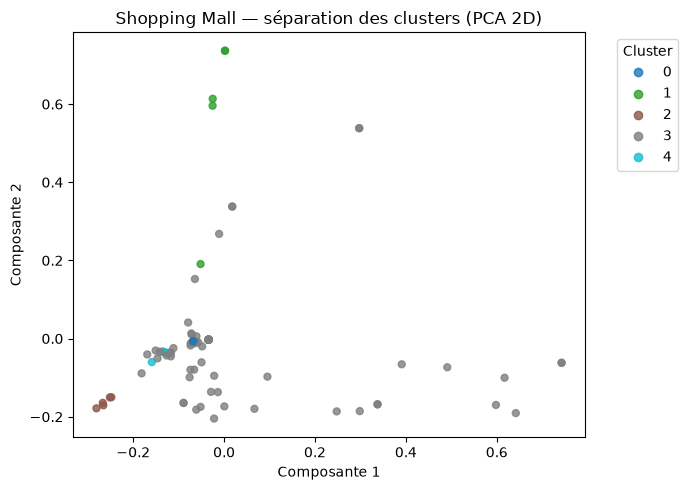

In [11]:
plot_clusters_2d(X_sm, df_shopping_mall["cluster"], "Shopping Mall — séparation des clusters (PCA 2D)")


### Étape 4b bis — Noms automatiques des clusters (Shopping Mall)


In [12]:
names_sm = name_clusters(vectorizer_sm, kmeans_sm, top_n=3)
for cluster_id, name in names_sm.items():
    print(f"Cluster {cluster_id} : {name}")


Cluster 0 : Machine
Cluster 1 : Installation / Composants / Deux
Cluster 2 : Matériel / Administratif / Formation
Cluster 3 : اقتناء / استشارة / Achat
Cluster 4 : Etude / Fois / Deuxième


Même chose ici si besoin : renommez à la main les clusters peu clairs.


In [13]:
NOMS_MANUELS_SM = {
    # 0: "Fournitures médicales",
    # 2: "Nettoyage et entretien",
}
names_sm.update(NOMS_MANUELS_SM)


## Étape 4 ter — Catégories métier claires (priorité Photovoltaïque / Solaire)

Plutôt que de se fier uniquement aux mots-clés statistiques du K-means, on définit ici des **catégories métier connues d'avance**, avec des noms clairs pour tout le monde. Le **photovoltaïque / énergie solaire** est vérifié en premier (priorité), car c'est le cœur de métier de la société — toute offre qui en parle sera classée ainsi, même si elle mentionne aussi d'autres mots.

Vous pouvez ajouter/modifier des mots-clés ou des catégories librement dans le dictionnaire ci-dessous.


In [14]:
import re

# Ordre = priorité (la première catégorie qui matche l'emporte).
# Ajoutez vos propres mots-clés ici si une offre importante n'est pas bien classée.
CATEGORIES_METIER = {
    "Photovoltaïque / Énergie solaire": [
        "photovoltaique", "photovoltaïque", "panneau solaire", "panneaux solaires",
        "energie solaire", "énergie solaire", "solaire", "onduleur", "kwc", "kw crete",
        "energie renouvelable", "énergie renouvelable", "renouvelable", "centrale solaire",
        "kit solaire", "cellule solaire", "module solaire", "module photovoltaique",
        "raccordement solaire", "toiture solaire",
        "الطاقة الشمسية", "الألواح الشمسية", "الواح شمسية", "طاقة شمسية", "طاقات متجددة",
        "الطاقات المتجددة", "كهروضوئي", "كهروضوئية", "الواح كهروضوئية", "خلايا شمسية", "شمسي",
    ],
    "Médical / Santé": [
        "medical", "médical", "hopital", "hôpital", "chirurgie", "laboratoire",
        "pharmaceutique", "reactif", "réactif", "clinique", "sanitaire",
        "طبية", "طبي", "مستشفى",
    ],
    "Travaux / Construction": [
        "travaux", "construction", "amenagement", "aménagement", "batiment", "bâtiment",
        "genie civil", "génie civil", "renovation", "rénovation", "electricite", "électricité",
        "أشغال", "بناء",
    ],
    "Informatique / IT": [
        "informatique", "logiciel", "serveur", "reseau informatique", "réseau informatique",
        "materiel informatique", "matériel informatique", "ordinateur", "imprimante",
        "معلوماتية", "حاسوب",
    ],
    "Nettoyage / Entretien": [
        "nettoyage", "entretien", "hygiene", "hygiène", "proprete", "propreté",
        "تنظيف",
    ],
    "Transport / Véhicules": [
        "vehicule", "véhicule", "transport", "voiture", "camion", "engin",
        "نقل", "سيارة",
    ],
    "Fournitures de bureau": [
        "papeterie", "fourniture de bureau", "fournitures de bureau", "bureautique",
        "مكتب",
    ],
    "Agriculture": [
        "agricole", "agriculture", "irrigation",
        "فلاحي", "زراعة",
    ],
}


def categorize(objet_text: str, fallback_name: str) -> str:
    """
    Renvoie la première catégorie métier dont un mot-clé apparaît dans le texte.
    Si aucune catégorie ne matche, on retombe sur le nom du cluster K-means
    (utile pour ne rien perdre, même hors des catégories connues d'avance).
    """
    text = str(objet_text).lower() if pd.notna(objet_text) else ""
    for category, keywords in CATEGORIES_METIER.items():
        for kw in keywords:
            if kw.lower() in text:
                return category
    return fallback_name


### Application aux deux volets


In [15]:
df_avis_ao["categorie_metier"] = [
    categorize(objet, names_ao[c])
    for objet, c in zip(df_avis_ao["objet_ao"], df_avis_ao["cluster"])
]
df_shopping_mall["categorie_metier"] = [
    categorize(objet, names_sm[c])
    for objet, c in zip(df_shopping_mall["objet_consultation"], df_shopping_mall["cluster"])
]

print("--- Avis A.O par catégorie métier ---")
print(df_avis_ao["categorie_metier"].value_counts())
print("\n--- Shopping Mall par catégorie métier ---")
print(df_shopping_mall["categorie_metier"].value_counts())


--- Avis A.O par catégorie métier ---
categorie_metier
Travaux / Construction               163
Mise / Profit / Installation         116
Médical / Santé                       50
اقتناء / لفائدة / معدات               21
Transport / Véhicules                 21
Deux / Lot / Tunisien                 20
Nettoyage / Entretien                 14
عروض / طلب / عدد                      12
Informatique / IT                     11
Matériels / Achat / Informatiques      7
Photovoltaïque / Énergie solaire       6
أشغال / تهيئة / إنجاز                  6
Fournitures de bureau                  5
Agriculture                            5
Construction / Exécution / Cadre       3
Aménagement / Réhabilitation / El      1
Name: count, dtype: int64

--- Shopping Mall par catégorie métier ---
categorie_metier
اقتناء / استشارة / Achat                57
Travaux / Construction                   9
Médical / Santé                          5
Nettoyage / Entretien                    5
Transport / Véhicules         

## Étape 5 — Sauvegarde des résultats

Chaque volet reste dans son propre fichier, avec juste une colonne `cluster` en plus — prêt pour le dashboard Streamlit (Agent4).


In [16]:
df_avis_ao["cluster_name"] = df_avis_ao["cluster"].map(names_ao)
df_shopping_mall["cluster_name"] = df_shopping_mall["cluster"].map(names_sm)

df_avis_ao.to_csv(f"{DATA_DIR}/clustered_avis_ao.csv", index=False, encoding="utf-8-sig")
df_shopping_mall.to_csv(f"{DATA_DIR}/clustered_shopping_mall.csv", index=False, encoding="utf-8-sig")

print("Sauvegardé : clustered_avis_ao.csv et clustered_shopping_mall.csv (avec cluster + cluster_name)")


Sauvegardé : clustered_avis_ao.csv et clustered_shopping_mall.csv (avec cluster + cluster_name)


## Étape 6 (optionnel) — Voir des exemples d'objets par cluster

Utile pour comprendre ce que chaque cluster représente (ex : cluster 0 = travaux, cluster 1 = informatique...).


In [17]:
for c in sorted(df_avis_ao["cluster"].unique()):
    print(f"\n--- Avis A.O — Cluster {c} : {names_ao[c]} ---")
    sample = df_avis_ao[df_avis_ao["cluster"] == c]
    print(f"Catégories métier trouvées : {sample['categorie_metier'].unique().tolist()}")
    print(sample["objet_ao"].head(3).to_string(index=False))



--- Avis A.O — Cluster 0 : Mise / Profit / Installation ---
Catégories métier trouvées : ['Travaux / Construction', 'Mise / Profit / Installation', 'Médical / Santé', 'Transport / Véhicules', 'Informatique / IT', 'Fournitures de bureau', 'Photovoltaïque / Énergie solaire', 'Nettoyage / Entretien', 'Agriculture']
travaux de réaménagement des hangars a KEF ANBA...
Désignation d'un avocat ou d'un cabinet d'avoca...
          تزويد المستشفي المحلي بسجنان بمعدات طبية

--- Avis A.O — Cluster 1 : Entretien / Primaire / École ---
Catégories métier trouvées : ['Médical / Santé', 'Nettoyage / Entretien', 'Travaux / Construction']
Travaux d'aménagement et entretien des bâtiment...
                    Entretien des ecoles primaires
Construction d'un espace préparatoire, aménagem...

--- Avis A.O — Cluster 2 : بناء / أشغال / استكمال ---
Catégories métier trouvées : ['Travaux / Construction', 'Médical / Santé']
بناء قاعتي تدريس عاديتين بالمدرسة الابتدائية طر...
إعلان مناظرة بالملفات اختيار أصحاب ال

In [18]:
for c in sorted(df_shopping_mall["cluster"].unique()):
    print(f"\n--- Shopping Mall — Cluster {c} : {names_sm[c]} ---")
    sample = df_shopping_mall[df_shopping_mall["cluster"] == c]
    print(f"Catégories métier trouvées : {sample['categorie_metier'].unique().tolist()}")
    print(sample["objet_consultation"].head(3).to_string(index=False))



--- Shopping Mall — Cluster 0 : Machine ---
Catégories métier trouvées : ['Machine']
                machine de reluire à chaud
Acquisition d'une machine à graver le bois

--- Shopping Mall — Cluster 1 : Installation / Composants / Deux ---
Catégories métier trouvées : ['Installation / Composants / Deux', 'Travaux / Construction']
Installation de deux ralentisseurs de vitesse a...
Se procurer les composants pour un projet d'inc...
Fourniture et installation d'une hampe porte-dr...

--- Shopping Mall — Cluster 2 : Matériel / Administratif / Formation ---
Catégories métier trouvées : ['Informatique / IT', 'Matériel / Administratif / Formation']
 acquisition matériel informatique
acquisition matériel administratif
             matériel de formation

--- Shopping Mall — Cluster 3 : اقتناء / استشارة / Achat ---
Catégories métier trouvées : ['اقتناء / استشارة / Achat', 'Médical / Santé', 'Photovoltaïque / Énergie solaire', 'Nettoyage / Entretien', 'Travaux / Construction', 'Fournitures de b